In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('MOD-00678.csv')
len(ts)

372611

In [4]:
ts = pd.read_csv('MOD-00678.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:38Z,7.221,0.804,0.196,0.017,0.037,0.012,5.072,762.896,34.986,2.403,27.638,49.5,0.4
1,2025-12-31T18:58:38Z,6.655,0.625,0.113,0.030,0.016,0.020,5.619,752.810,37.115,2.402,25.989,49.1,0.3
2,2025-12-31T18:57:38Z,6.896,0.719,0.185,0.018,0.023,0.017,5.458,766.214,36.403,2.468,25.507,49.3,0.3
3,2025-12-31T18:56:38Z,7.017,0.791,0.154,0.019,0.026,0.011,5.314,760.254,36.735,2.467,25.968,49.6,0.3
4,2025-12-31T18:55:38Z,6.525,0.657,0.140,0.024,0.019,0.008,5.181,756.560,35.683,2.402,26.916,49.6,0.3


In [5]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:38,7.221,0.804,0.196,0.017,0.037,0.012,5.072,762.896,34.986,2.403,27.638,49.5,0.4
1,2025-12-31 18:58:38,6.655,0.625,0.113,0.030,0.016,0.020,5.619,752.810,37.115,2.402,25.989,49.1,0.3
2,2025-12-31 18:57:38,6.896,0.719,0.185,0.018,0.023,0.017,5.458,766.214,36.403,2.468,25.507,49.3,0.3
3,2025-12-31 18:56:38,7.017,0.791,0.154,0.019,0.026,0.011,5.314,760.254,36.735,2.467,25.968,49.6,0.3
4,2025-12-31 18:55:38,6.525,0.657,0.140,0.024,0.019,0.008,5.181,756.560,35.683,2.402,26.916,49.6,0.3


## Full Timeseries Plot

In [6]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15,2.393522,0.293443,0.113405,0.030884,0.044222,0.031903,3.440744,830.082914,61.873083,2.729303,12.925880,35.704018,17.328571
2025-04-16,1.511646,0.165231,0.056620,0.011826,0.014308,0.009439,2.053975,788.420538,56.881954,2.056067,11.352887,38.712117,10.746031
2025-04-17,3.225099,0.340179,0.118595,0.027067,0.032678,0.020560,3.199624,817.627283,58.887074,2.049324,13.553853,29.614028,14.904514
2025-04-18,6.756051,1.040031,0.461052,0.137342,0.179975,0.136057,8.208451,948.014680,57.344217,3.785942,20.751387,34.384028,16.907917
2025-04-19,13.037188,1.255908,0.547993,0.173562,0.242893,0.195065,17.487826,880.492309,58.857942,2.725759,19.395932,49.512083,22.940139


In [7]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15,2.393522,0.293443,0.113405,0.030884,0.044222,0.031903,3.440744,830.082914,61.873083,2.729303,12.925880,35.704018,17.328571,5.007780
2025-04-16,1.511646,0.165231,0.056620,0.011826,0.014308,0.009439,2.053975,788.420538,56.881954,2.056067,11.352887,38.712117,10.746031,3.606842
2025-04-17,3.225099,0.340179,0.118595,0.027067,0.032678,0.020560,3.199624,817.627283,58.887074,2.049324,13.553853,29.614028,14.904514,4.985440
2025-04-18,6.756051,1.040031,0.461052,0.137342,0.179975,0.136057,8.208451,948.014680,57.344217,3.785942,20.751387,34.384028,16.907917,7.786573
2025-04-19,13.037188,1.255908,0.547993,0.173562,0.242893,0.195065,17.487826,880.492309,58.857942,2.725759,19.395932,49.512083,22.940139,12.842729


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27352/3682742719.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


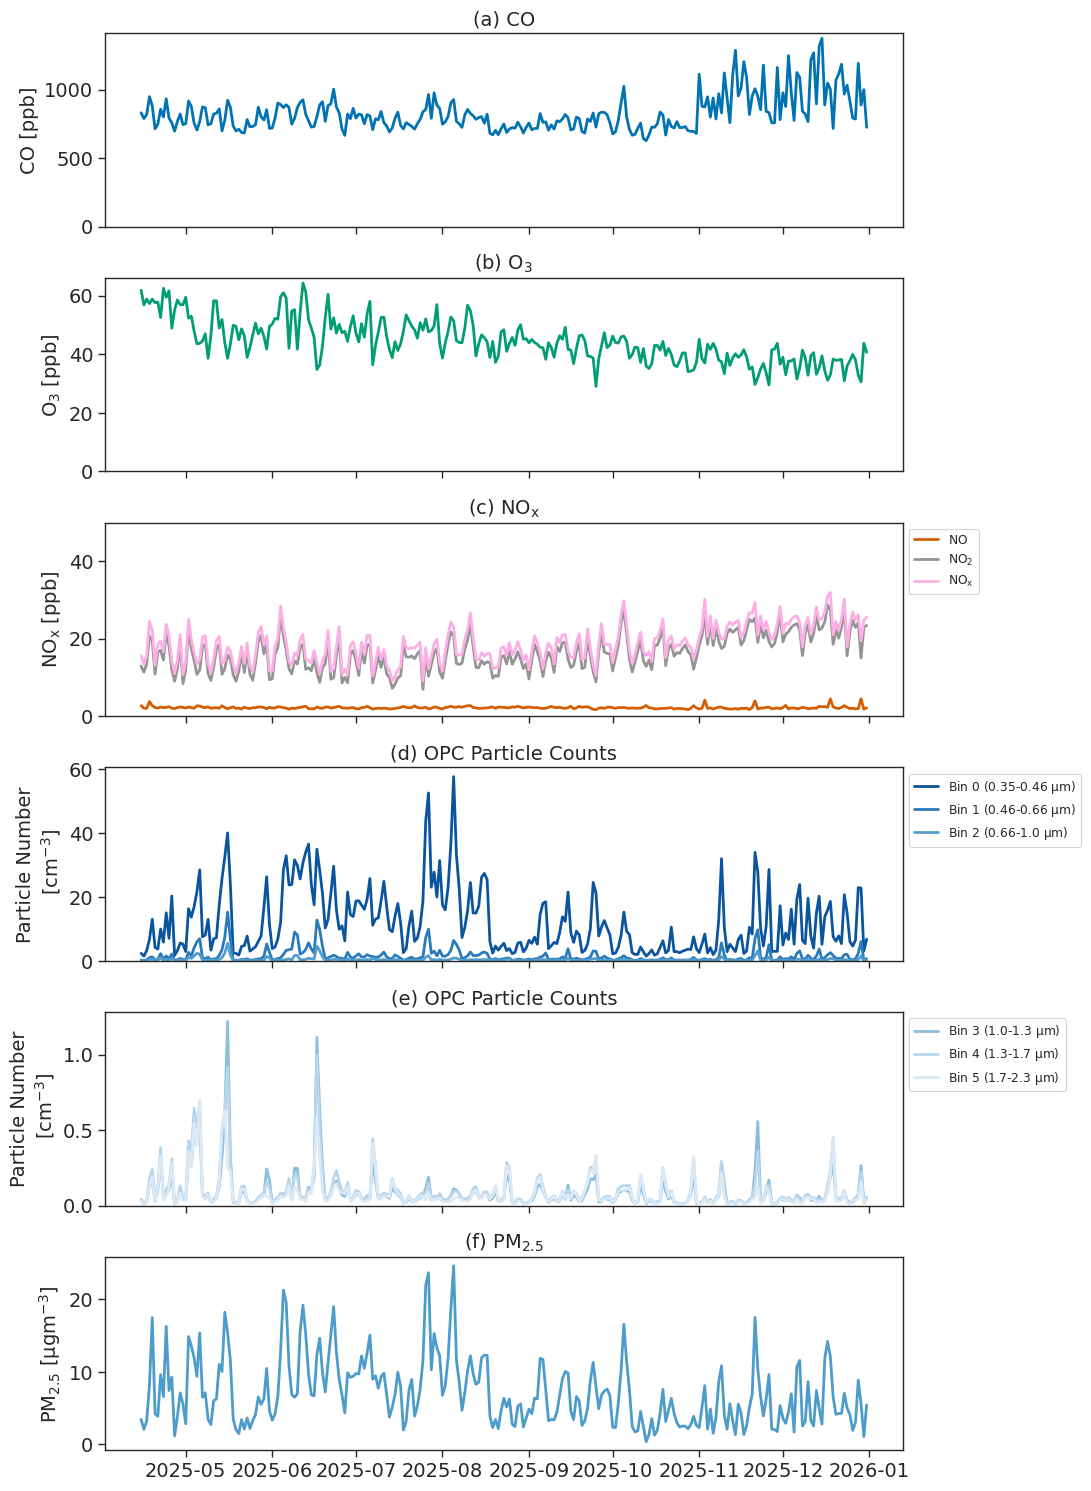

In [8]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

fig.savefig('timeseries_MOD-00678.png')

## Dirunal Plots

In [9]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15 08:00:00,5.698700,0.604000,0.212650,0.047900,0.050650,0.028400,8.562150,NaN,NaN,NaN,NaN,36.375000,22.265000
2025-04-15 13:00:00,5.039558,0.480827,0.186154,0.050231,0.083192,0.061635,7.892808,NaN,NaN,NaN,NaN,31.236538,23.207692
2025-04-15 14:00:00,3.775350,0.448350,0.172000,0.050900,0.074133,0.058500,6.156117,933.857333,68.753627,3.400588,7.564510,25.185000,23.760000
2025-04-15 15:00:00,2.201133,0.326250,0.141250,0.050383,0.080733,0.063350,5.218850,829.547167,68.355017,3.695750,7.105917,24.200000,23.113333
2025-04-15 16:00:00,1.840867,0.284867,0.133133,0.045833,0.073467,0.054200,4.247450,796.156067,65.488250,2.657817,15.649600,27.896667,20.928333


In [10]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15 08:00:00,5.698700,0.604000,0.212650,0.047900,0.050650,0.028400,8.562150,NaN,NaN,NaN,NaN,36.375000,22.265000,6.648771
2025-04-15 13:00:00,5.039558,0.480827,0.186154,0.050231,0.083192,0.061635,7.892808,NaN,NaN,NaN,NaN,31.236538,23.207692,6.373118
2025-04-15 14:00:00,3.775350,0.448350,0.172000,0.050900,0.074133,0.058500,6.156117,933.857333,68.753627,3.400588,7.564510,25.185000,23.760000,5.737963
2025-04-15 15:00:00,2.201133,0.326250,0.141250,0.050383,0.080733,0.063350,5.218850,829.547167,68.355017,3.695750,7.105917,24.200000,23.113333,5.402684
2025-04-15 16:00:00,1.840867,0.284867,0.133133,0.045833,0.073467,0.054200,4.247450,796.156067,65.488250,2.657817,15.649600,27.896667,20.928333,5.092677


In [11]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-04-15 08:00:00,5.698700,0.604000,0.212650,0.047900,0.050650,0.028400,8.562150,NaN,NaN,NaN,NaN,36.375000,22.265000,6.648771,8
2025-04-15 13:00:00,5.039558,0.480827,0.186154,0.050231,0.083192,0.061635,7.892808,NaN,NaN,NaN,NaN,31.236538,23.207692,6.373118,13
2025-04-15 14:00:00,3.775350,0.448350,0.172000,0.050900,0.074133,0.058500,6.156117,933.857333,68.753627,3.400588,7.564510,25.185000,23.760000,5.737963,14
2025-04-15 15:00:00,2.201133,0.326250,0.141250,0.050383,0.080733,0.063350,5.218850,829.547167,68.355017,3.695750,7.105917,24.200000,23.113333,5.402684,15
2025-04-15 16:00:00,1.840867,0.284867,0.133133,0.045833,0.073467,0.054200,4.247450,796.156067,65.488250,2.657817,15.649600,27.896667,20.928333,5.092677,16


In [12]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,12.789554,2.066780,0.587014,0.125496,0.130086,0.092707,7.289587,835.903701,43.000956,2.094525,17.649689,62.135575,17.215581,6.635330
01:00,12.904688,1.986345,0.530781,0.110084,0.119841,0.094915,7.291987,829.383212,42.348161,2.105047,17.422712,63.435003,16.830443,6.647974
02:00,12.556368,1.790205,0.461000,0.099086,0.114783,0.097281,6.965532,815.000348,41.668256,2.114924,17.195488,64.718209,16.459130,6.562922
03:00,12.688721,1.808558,0.468800,0.102022,0.117433,0.098040,6.776646,800.372932,40.814013,2.046216,16.692155,65.830178,16.110494,6.515889
04:00,12.871733,1.894508,0.513622,0.115723,0.130545,0.106501,6.856499,808.745845,39.799289,2.024867,16.977053,66.981314,15.810267,6.552302
05:00,13.337836,2.020569,0.555201,0.124942,0.137881,0.109818,6.946407,833.396438,38.478918,2.021397,17.821939,67.959302,15.580168,6.591061
06:00,13.269520,1.966786,0.539126,0.121813,0.137243,0.111925,7.075359,862.750391,37.149525,2.100978,18.173370,67.379387,15.735275,6.623326
07:00,13.041634,1.859813,0.493410,0.111296,0.128607,0.104409,7.098693,863.774153,36.578580,2.369979,16.716468,63.027349,17.150733,6.596604
08:00,12.799377,1.764768,0.458883,0.099517,0.113138,0.086236,7.167858,844.724815,37.228317,2.557723,14.376333,56.052263,19.516769,6.568114


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27352/2390676921.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_27352/2390676921.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blu

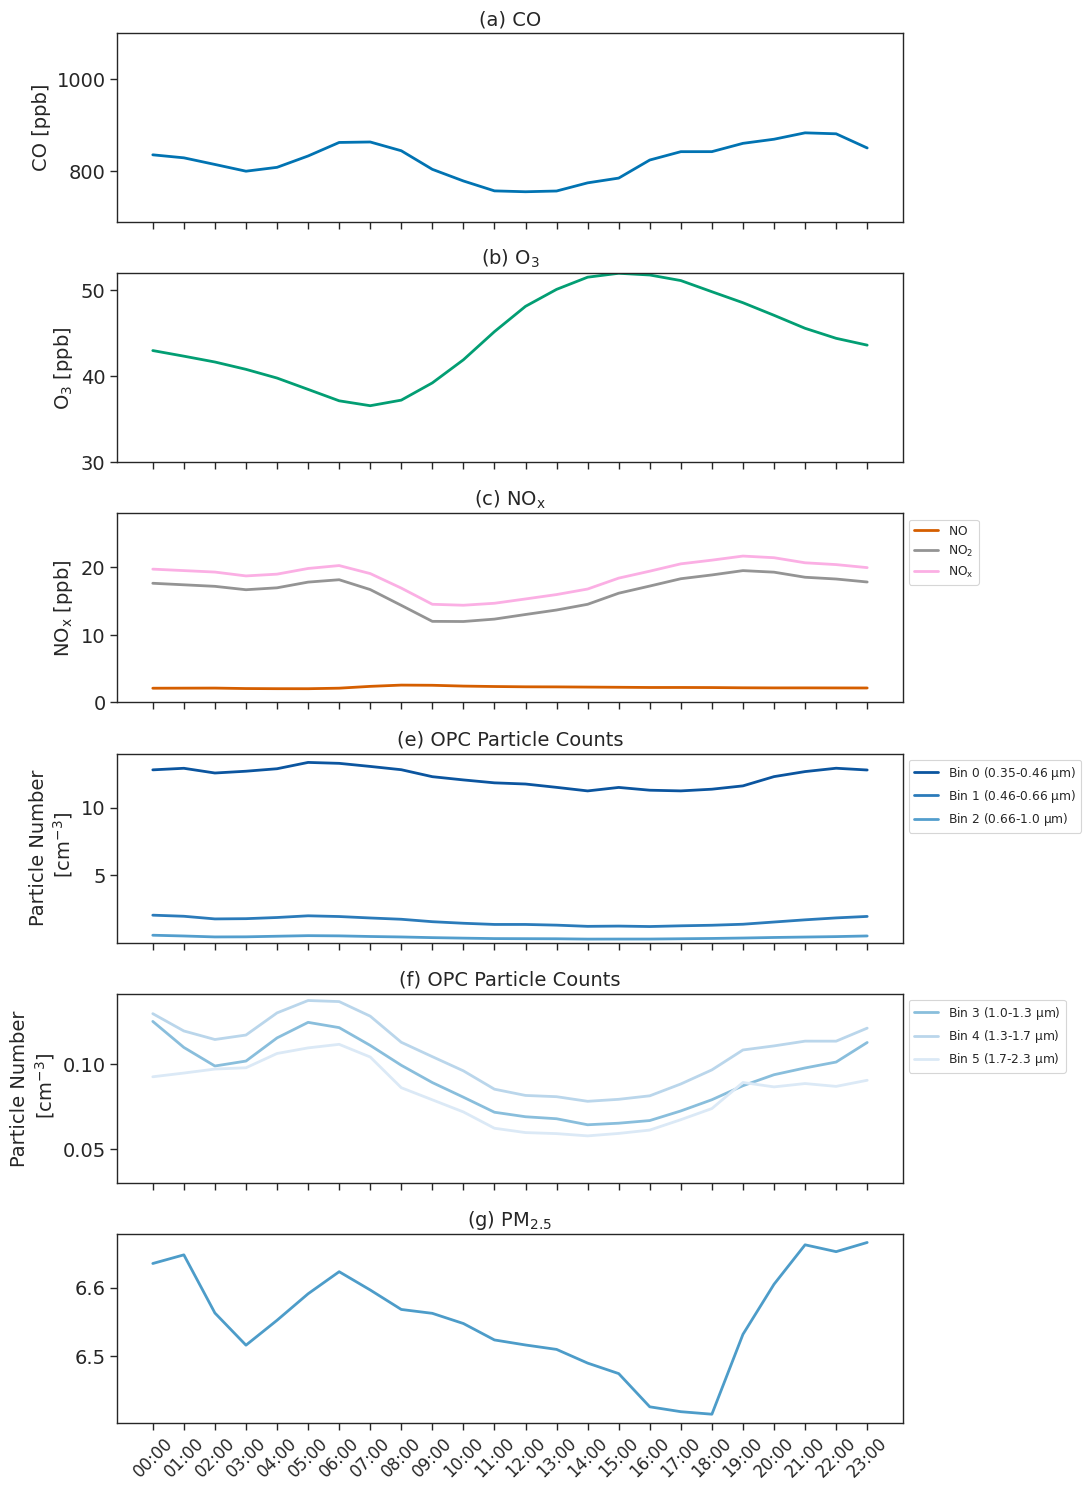

In [13]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 1100)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.03, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('dirunal_MOD-00678_allfeatures.png')

## Diurnal by Season

In [14]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [15]:
ts_hour = ts_hour.reset_index()

In [16]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-04-15 08:00:00,5.698700,0.604000,0.212650,0.047900,0.050650,0.028400,8.562150,NaN,NaN,NaN,NaN,36.375000,22.265000,6.648771,8,Spring
1,2025-04-15 13:00:00,5.039558,0.480827,0.186154,0.050231,0.083192,0.061635,7.892808,NaN,NaN,NaN,NaN,31.236538,23.207692,6.373118,13,Spring
2,2025-04-15 14:00:00,3.775350,0.448350,0.172000,0.050900,0.074133,0.058500,6.156117,933.857333,68.753627,3.400588,7.564510,25.185000,23.760000,5.737963,14,Spring
3,2025-04-15 15:00:00,2.201133,0.326250,0.141250,0.050383,0.080733,0.063350,5.218850,829.547167,68.355017,3.695750,7.105917,24.200000,23.113333,5.402684,15,Spring
4,2025-04-15 16:00:00,1.840867,0.284867,0.133133,0.045833,0.073467,0.054200,4.247450,796.156067,65.488250,2.657817,15.649600,27.896667,20.928333,5.092677,16,Spring


In [18]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      7.531713  1.173787  0.394463  0.091092  0.100184  0.073495   
       1      7.818774  1.017106  0.303126  0.067439  0.080480  0.068260   
       2      8.109506  1.004989  0.296932  0.067456  0.082432  0.072486   
       3      8.500323  1.037195  0.298719  0.068468  0.083322  0.073943   
       4      8.950249  1.145066  0.317805  0.069468  0.081207  0.068169   
...                ...       ...       ...       ...       ...       ...   
Winter 19    11.449606  1.295973  0.315648  0.062388  0.080309  0.060477   
       20    11.507859  1.318694  0.307230  0.057800  0.070660  0.053100   
       21    11.720243  1.448615  0.356101  0.071913  0.089481  0.068648   
       22    12.696278  1.727906  0.403208  0.082604  0.101027  0.075963   
       23    14.756381  2.394099  0.529353  0.103212  0.113709  0.078058   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     5.201894  791.538875  39.817208  2.021768  17.862996  61.028820   
       1     5.120763  790.607233  39.139174  2.072650  18.352758  62.859466   
       2     5.130904  792.790955  38.380629  2.159590  18.931940  64.493596   
       3     5.079624  774.709014  37.454740  1.985111  18.558986  65.817837   
       4     4.961519  763.553483  36.623440  1.962220  19.022273  66.986993   
...               ...         ...        ...       ...        ...        ...   
Winter 19    5.710186  897.258953  36.545745  2.036671  24.111201  55.010500   
       20    5.755312  956.412317  36.138969  2.077344  23.909217  55.120386   
       21    5.877488  947.967776  36.015514  2.074829  23.676056  55.927556   
       22    5.953339  976.436442  36.206851  2.096795  24.085814  57.192611   
       23    6.324387  901.913089  35.760352  2.192312  23.739213  58.822556   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.453596  5.898536  
       1     15.022182  5.896724  
       2     14.661442  5.920928  
       3     14.337837  5.921248  
       4     14.040006  5.899221  
...                ...       ...  
Winter 19     2.727778  5.269276  
       20     2.620985  5.280022  
       21     2.455167  5.327511  
       22     2.327389  5.374087  
       23     2.009833  5.507900  

[96 rows x 14 columns]

In [19]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,7.531713,1.173787,0.394463,0.091092,0.100184,0.073495,5.201894,791.538875,39.817208,2.021768,17.862996,61.028820,15.453596,5.898536
1,Autumn,1,7.818774,1.017106,0.303126,0.067439,0.080480,0.068260,5.120763,790.607233,39.139174,2.072650,18.352758,62.859466,15.022182,5.896724
2,Autumn,2,8.109506,1.004989,0.296932,0.067456,0.082432,0.072486,5.130904,792.790955,38.380629,2.159590,18.931940,64.493596,14.661442,5.920928
3,Autumn,3,8.500323,1.037195,0.298719,0.068468,0.083322,0.073943,5.079624,774.709014,37.454740,1.985111,18.558986,65.817837,14.337837,5.921248
4,Autumn,4,8.950249,1.145066,0.317805,0.069468,0.081207,0.068169,4.961519,763.553483,36.623440,1.962220,19.022273,66.986993,14.040006,5.899221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,11.449606,1.295973,0.315648,0.062388,0.080309,0.060477,5.710186,897.258953,36.545745,2.036671,24.111201,55.010500,2.727778,5.269276
92,Winter,20,11.507859,1.318694,0.307230,0.057800,0.070660,0.053100,5.755312,956.412317,36.138969,2.077344,23.909217,55.120386,2.620985,5.280022
93,Winter,21,11.720243,1.448615,0.356101,0.071913,0.089481,0.068648,5.877488,947.967776,36.015514,2.074829,23.676056,55.927556,2.455167,5.327511
94,Winter,22,12.696278,1.727906,0.403208,0.082604,0.101027,0.075963,5.953339,976.436442,36.206851,2.096795,24.085814,57.192611,2.327389,5.374087


In [20]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [21]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,7.531713,1.173787,0.394463,0.091092,0.100184,0.073495,5.201894,791.538875,39.817208,2.021768,17.862996,61.028820,15.453596,5.898536
01:00,Autumn,1,7.818774,1.017106,0.303126,0.067439,0.080480,0.068260,5.120763,790.607233,39.139174,2.072650,18.352758,62.859466,15.022182,5.896724
02:00,Autumn,2,8.109506,1.004989,0.296932,0.067456,0.082432,0.072486,5.130904,792.790955,38.380629,2.159590,18.931940,64.493596,14.661442,5.920928
03:00,Autumn,3,8.500323,1.037195,0.298719,0.068468,0.083322,0.073943,5.079624,774.709014,37.454740,1.985111,18.558986,65.817837,14.337837,5.921248
04:00,Autumn,4,8.950249,1.145066,0.317805,0.069468,0.081207,0.068169,4.961519,763.553483,36.623440,1.962220,19.022273,66.986993,14.040006,5.899221
05:00,Autumn,5,9.647148,1.384087,0.376101,0.076607,0.081561,0.065849,5.011570,818.497399,35.720434,1.991411,19.498025,68.184551,13.807753,5.931265
06:00,Autumn,6,9.957692,1.460767,0.406424,0.082013,0.084175,0.065585,5.120742,858.696212,34.331990,2.114251,20.417290,69.112041,13.522250,5.971783
07:00,Autumn,7,9.664078,1.238214,0.337704,0.071728,0.080804,0.064862,5.222951,850.502468,33.768393,2.299662,19.636799,66.262667,14.462704,5.980878
08:00,Autumn,8,8.831842,1.028572,0.292392,0.066131,0.080021,0.063608,5.630449,854.100545,34.008808,2.324882,15.852380,58.099685,17.046667,6.035599
09:00,Autumn,9,7.853296,0.918942,0.277936,0.064837,0.080338,0.062953,5.693857,812.075157,35.651013,2.547462,12.438083,50.867959,19.550827,6.006142


In [22]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27352/2127381206.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_27352/2127381206.py:41: SyntaxWarning: invalid escape sequence '

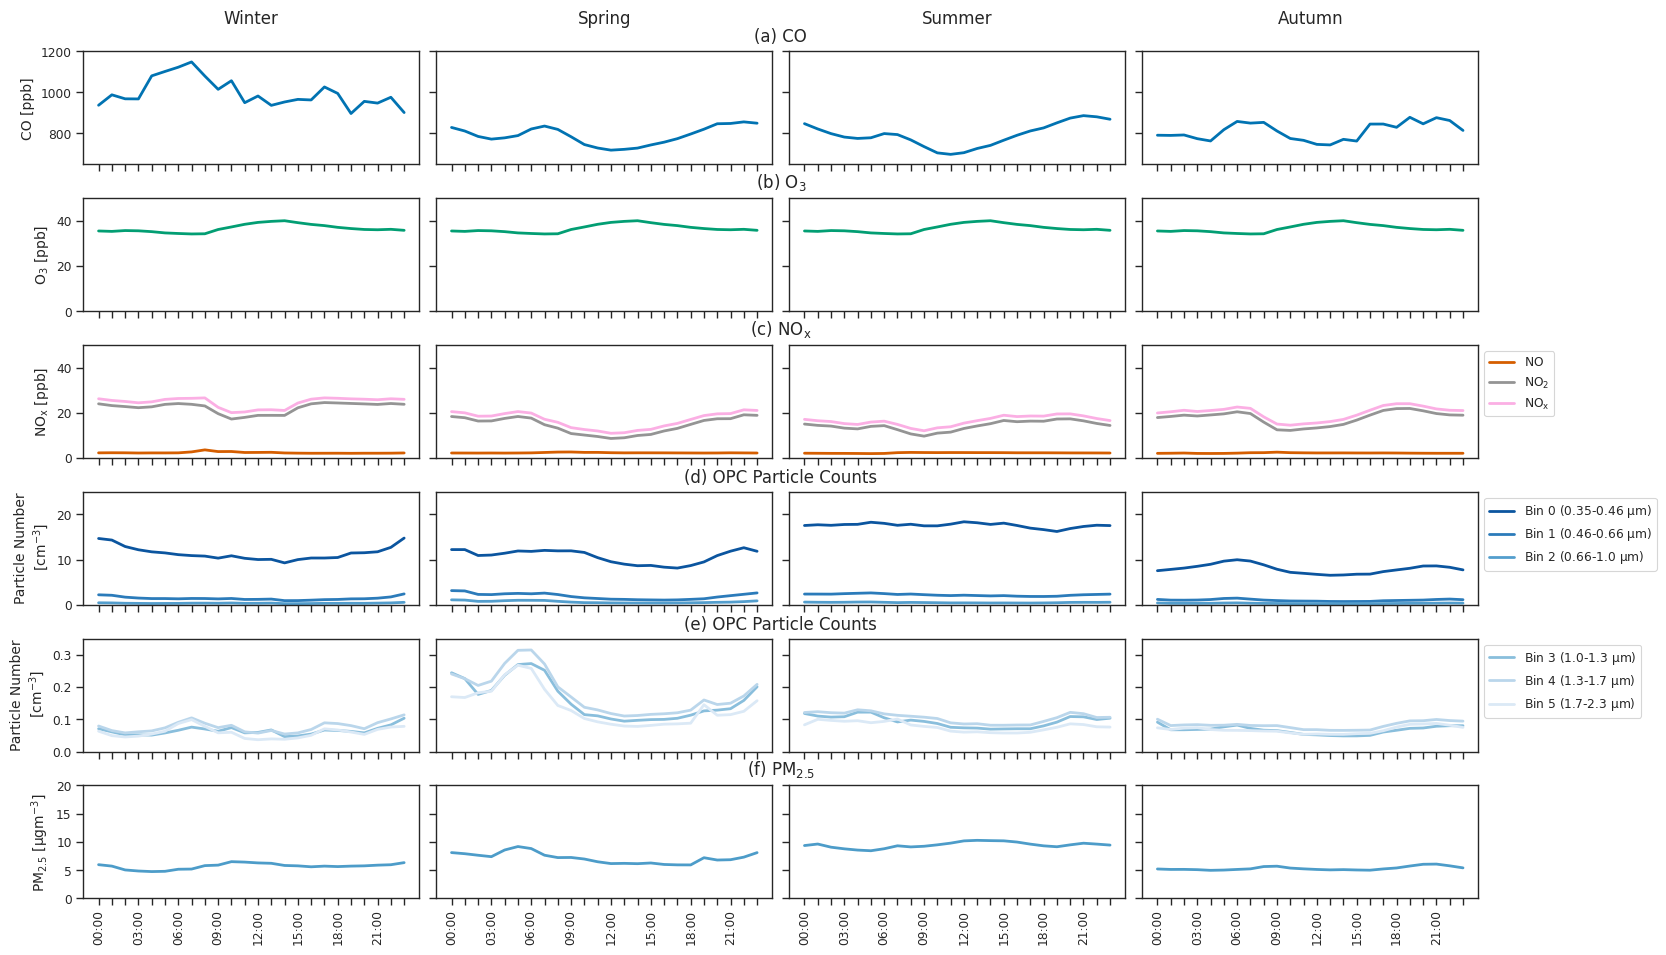

In [23]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 1200)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticks(range(24))
    ax[5,i].set_xticklabels(
    ['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''],
    rotation=90
)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('diurnal_by_season_MOD-00678.png')